In [2]:
#Autor: Pedro Javier Ortega Fernandez
#Titulación: Doble Grado Matemáticas e Ingeniería Informática

In [35]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate
import time

from metricas_utils import Accuracy, Recall, Precision, TNR, F1_score, Auc

In [ ]:
#Métricas para cada experimento
def calc_metrics(dataframe):
    threadshold = 0.5
    return{
        'ACCURACY': Accuracy(dataframe, threadshold),
        'RECALL': Recall(dataframe, threadshold),
        'PRECISION': Precision(dataframe, threadshold),
        'TNR': TNR(dataframe, threadshold),
        'F1': F1_score(dataframe, threadshold),
        'AUC-ROC': Auc(dataframe)
    }



In [4]:
dataset = pd.read_csv('data/decision_tree_dataset.csv')

# Separate atributes and target

X = dataset.iloc[: , :-1]
y = dataset.iloc[:, -1]


In [76]:
every_experiment = []

In [77]:
# 10 times Hold-out
for i in range(10):
    initial_time = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    df_aux = pd.DataFrame({
        'gt': y_test,
        'pred': y_pred
    })

    metrics = calc_metrics(df_aux)
    metrics['METHOD'] = 'Hold Out'
    metrics['TIME'] = time.time() - initial_time

    every_experiment.append(metrics)

    # Not neccessary since it calculates acuraccy
    # metrics_holdout.append(model.score(X_test, y_test))


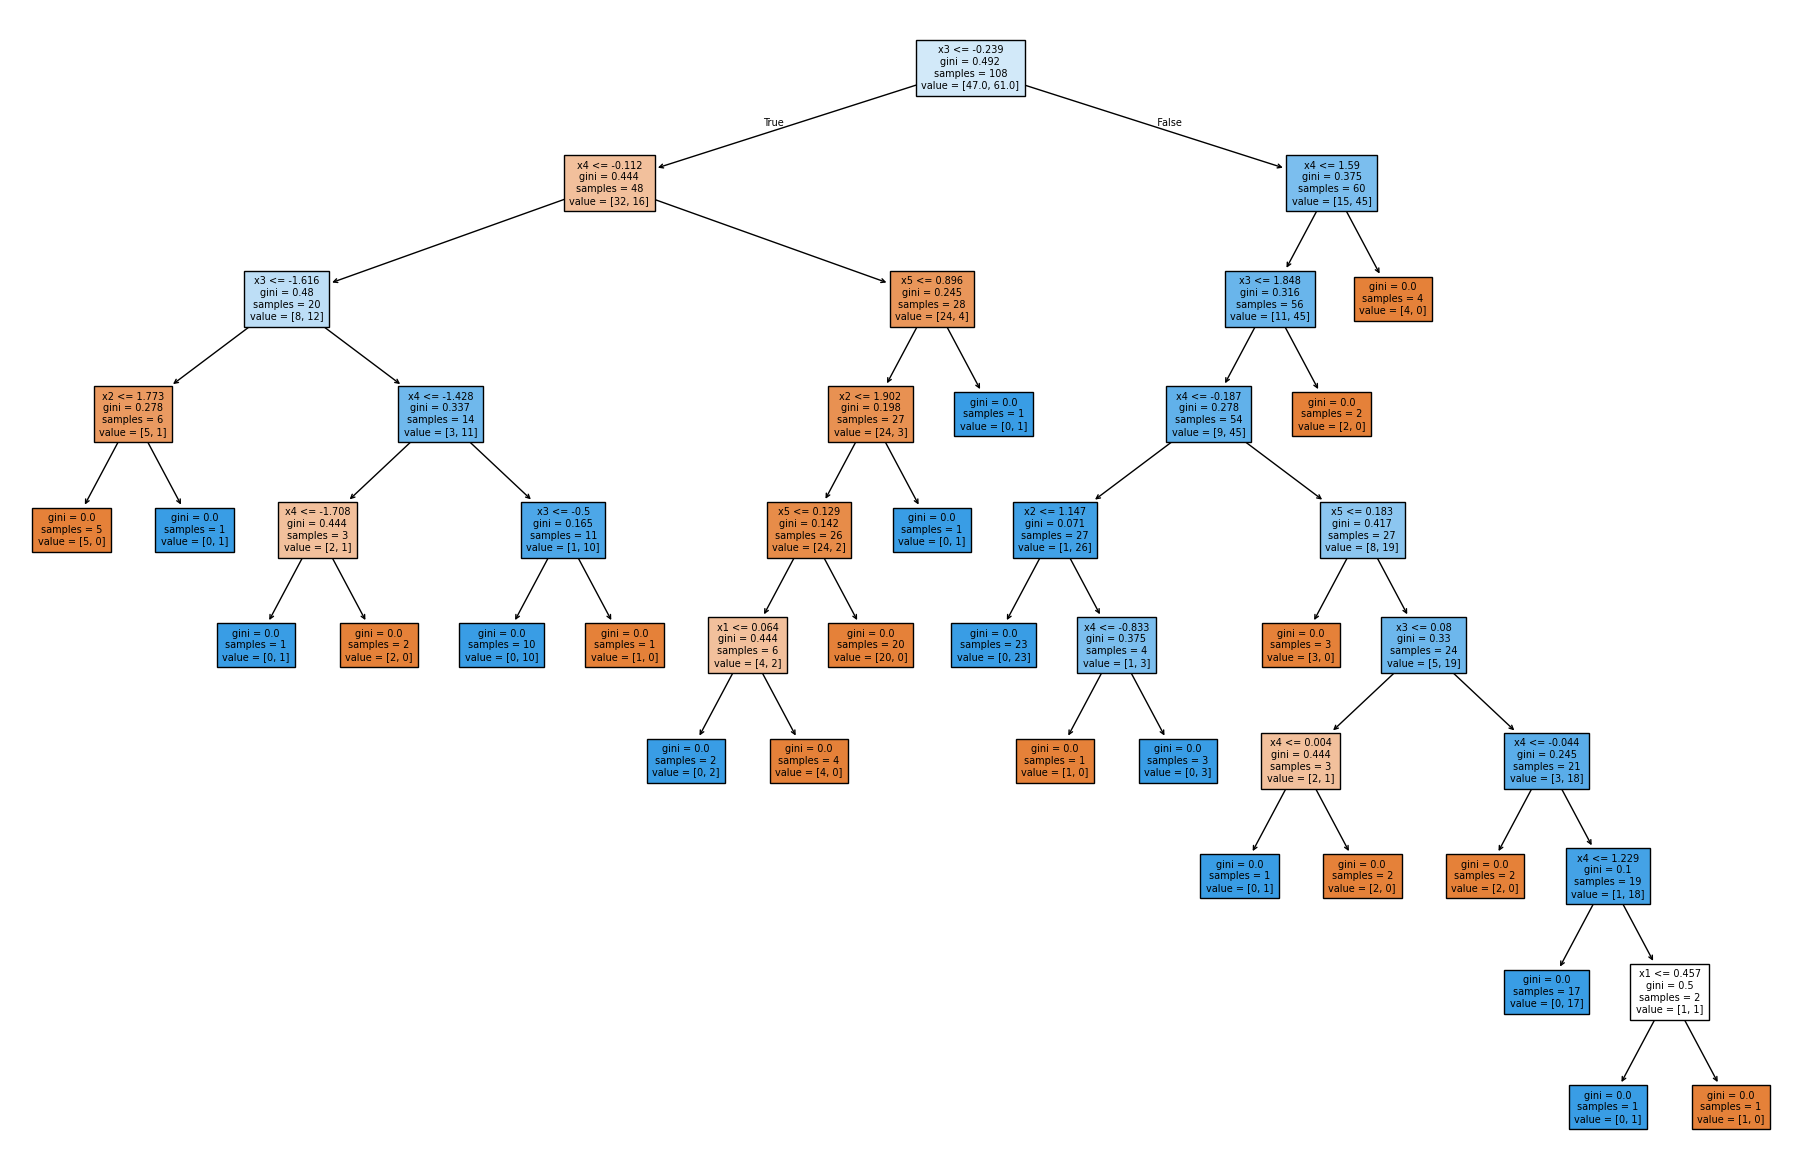

In [74]:
#Visualizamos el ultimo modelo
plt.figure(figsize=(23, 15))
plot_tree(decision_tree=model, feature_names=dataset.columns, filled= True, fontsize=7);

In [78]:
# 10 times Cross Validation (manual)

for i in range(10):
    initial_time = time.time()
    kf = KFold(n_splits=10, shuffle=True)
    
    # Store metrics of each fold
    fold_metrics = []  
    for train_index, test_index in kf.split(X):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = DecisionTreeClassifier()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        df_fold_aux = pd.DataFrame({
            'gt': y_test,
            'pred': y_pred
        })

        fold_metrics.append(calc_metrics(df_fold_aux))

    metrics = pd.DataFrame(fold_metrics).mean().to_dict()
    metrics['METHOD'] = 'CV Manual'
    metrics['TIME'] = time.time() - initial_time
    every_experiment.append(metrics)


In [79]:
# 10 times Cross Validation (automatic)
mi_scoring = {
    'Accuracy': 'accuracy',
    'Recall': 'recall',
    'Precision': 'precision',
    'F1': 'f1',
    'AUC-ROC': 'roc_auc'
}

for i in range(10):
    initial_time = time.time()
    kf = KFold(n_splits=10, shuffle=True)
    model = DecisionTreeClassifier()
    
    cv_res = cross_validate(model, X, y, cv=kf, scoring=mi_scoring)

    metrics = {
        'ACCURACY': np.mean(cv_res['test_Accuracy']),
        'RECALL': np.mean(cv_res['test_Recall']),
        'PRECISION': np.mean(cv_res['test_Precision']),
        'F1': np.mean(cv_res['test_F1']),
        'AUC-ROC': np.mean(cv_res['test_AUC-ROC']),
        # El TNR no está de manera nativa en sklearn
        'TNR': '--',
        'METHOD': 'CV Sklearn',
        'TIME': time.time() - initial_time
    }
    every_experiment.append(metrics)

In [80]:
every_experiment_dataframe = pd.DataFrame(every_experiment)
display(every_experiment_dataframe)

,ACCURACY,RECALL,PRECISION,TNR,F1,AUC-ROC,METHOD,TIME
0,0.833333,0.800000,1.000000,1.0,0.888889,0.900000,Hold Out,0.010360
1,0.750000,0.750000,0.857143,0.75,0.800000,0.750000,Hold Out,0.010677
2,0.750000,0.714286,0.833333,0.8,0.769231,0.757143,Hold Out,0.003785
3,0.750000,0.750000,0.600000,0.75,0.666667,0.750000,Hold Out,0.011070
4,0.416667,0.555556,0.625000,0.0,0.588235,0.277778,Hold Out,0.007283
5,0.666667,0.777778,0.777778,0.333333,0.777778,0.555556,Hold Out,0.008446
6,0.750000,0.666667,1.000000,1.0,0.800000,0.833333,Hold Out,0.004522
7,0.750000,1.000000,0.727273,0.25,0.842105,0.625000,Hold Out,0.007994
8,0.833333,0.750000,1.000000,1.0,0.857143,0.875000,Hold Out,0.006274
9,0.916667,1.000000,0.857143,0.833333,0.923077,0.916667,Hold Out,0.005654
